In [ ]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/AGRICULTURE(26.10.2025)new.xlsx'
df = pd.read_excel(file_path)
display(df.head())

Mounted at /content/drive


,Sensor_ID,Product_Name,Product_Type,Weather_Preference,States_Preference,Region_Preference,Soil_Moisture_%,Temperature_C,Humidity_%,Pest_Risk_%,Irrigation_Needed,Fertilizer_Required
0,1,Wheat,Cereal Crop,Cool & Dry (Rabi),"Punjab, UP, MP",Plains,20–30%,15–25°C,50–60%,15–25%,Yes (2–3 cycles),"Urea, DAP, Potash"
1,2,Rice,Cereal Crop,Warm & Humid (Kharif),"WB, TN, AP, Bihar",Plain/Delta,40–60%,25–35°C,70–90%,30–50%,Yes (Flood/Irrigation),"Urea, SSP, MOP"
2,3,Mango,Fruit Tree,Warm & Dry Summer,"Maharashtra, UP",Tropical/Subtropical,15–25%,24–30°C,50–70%,20–30%,Moderate (Flowering),"FYM, Potash, Zinc"
3,4,Apple,Fruit Tree,Cold & Temperate,"HP, J&K, Uttarakhand",Hills,20–30%,10–20°C,40–60%,10–20%,Yes (Drip),"FYM, Calcium, Boron"
4,5,Banana,Fruit Crop,Warm & Humid,"TN, Kerala, MH",Tropical,60–80%,26–30°C,80–90%,25–35%,High (Weekly),"NPK, FYM, Magnesium"


In [ ]:
import numpy as np

df = df.drop(df.iloc[:, 12:27], axis=1)

# Function to clean range columns (e.g., '20–30%') and convert to numeric
def clean_range_column(df, column_name, suffix=''):
    # Remove the suffix (like % or °C) and split the range by '–'
    df[column_name] = df[column_name].astype(str).str.replace(suffix, '').str.split('–')
    # Convert the split range strings to numeric, coercing errors to NaN
    df[column_name] = df[column_name].apply(lambda x: [pd.to_numeric(i, errors='coerce') for i in x])
    # Calculate the mean of the range, or keep the single value if not a range
    df[column_name] = df[column_name].apply(lambda x: np.mean(x) if isinstance(x, list) and len(x) > 0 else (x[0] if isinstance(x, list) and len(x) == 1 else np.nan))
    return df

# Apply the cleaning function to the relevant columns
df = clean_range_column(df, 'Soil_Moisture_%', '%')
df = clean_range_column(df, 'Humidity_%', '%')
df = clean_range_column(df, 'Temperature_C', '°C')
df = clean_range_column(df, 'Pest_Risk_%', '%')


# Calculate the mean of the specified columns for each row
df['Row_Mean'] = df[['Soil_Moisture_%', 'Humidity_%', 'Temperature_C', 'Pest_Risk_%']].mean(axis=1)

# Define the path for the new CSV file
output_csv_path = '/content/drive/My Drive/Original_Data_with_Row_Mean.csv'

# Save the DataFrame with the new 'Row_Mean' column to a new CSV file
df.to_csv(output_csv_path, index=False)

print(f"Original data with row-wise mean saved to {output_csv_path}")

# Display the first few rows of the updated DataFrame to show the new column
display(df.head())

Original data with row-wise mean saved to /content/drive/My Drive/Original_Data_with_Row_Mean.csv


,Sensor_ID,Product_Name,Product_Type,Weather_Preference,States_Preference,Region_Preference,Soil_Moisture_%,Temperature_C,Humidity_%,Pest_Risk_%,Irrigation_Needed,Fertilizer_Required,Row_Mean
0,1,Wheat,Cereal Crop,Cool & Dry (Rabi),"Punjab, UP, MP",Plains,25.0,20.0,55.0,20.0,Yes (2–3 cycles),"Urea, DAP, Potash",30.00
1,2,Rice,Cereal Crop,Warm & Humid (Kharif),"WB, TN, AP, Bihar",Plain/Delta,50.0,30.0,80.0,40.0,Yes (Flood/Irrigation),"Urea, SSP, MOP",50.00
2,3,Mango,Fruit Tree,Warm & Dry Summer,"Maharashtra, UP",Tropical/Subtropical,20.0,27.0,60.0,25.0,Moderate (Flowering),"FYM, Potash, Zinc",33.00
3,4,Apple,Fruit Tree,Cold & Temperate,"HP, J&K, Uttarakhand",Hills,25.0,15.0,50.0,15.0,Yes (Drip),"FYM, Calcium, Boron",26.25
4,5,Banana,Fruit Crop,Warm & Humid,"TN, Kerala, MH",Tropical,70.0,28.0,85.0,30.0,High (Weekly),"NPK, FYM, Magnesium",53.25


sort data for kMeans

In [ ]:
df = pd.read_excel(file_path)

# Drop empty rows
df.dropna(subset=["Product_Name", "Pest_Risk_%"], inplace=True)

# Convert range strings to numeric averages
def parse_range(value):
    if isinstance(value, str) and "–" in value:
        parts = value.replace("%", "").replace("°C", "").split("–")
        return (float(parts[0]) + float(parts[1])) / 2
    return value

for col in ["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Pest_Risk_%"]:
    df[col] = df[col].apply(parse_range)

In [ ]:
features = df[["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Pest_Risk_%"]]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

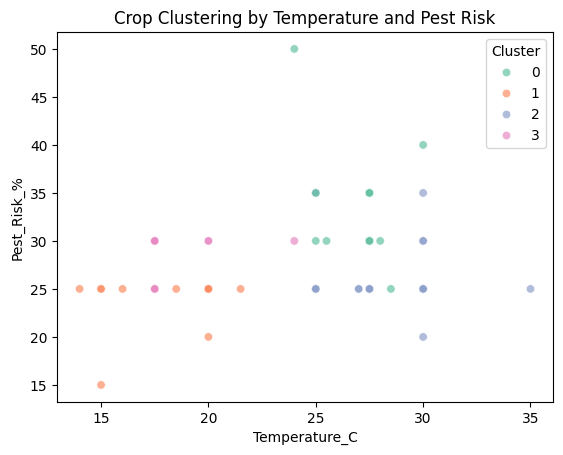

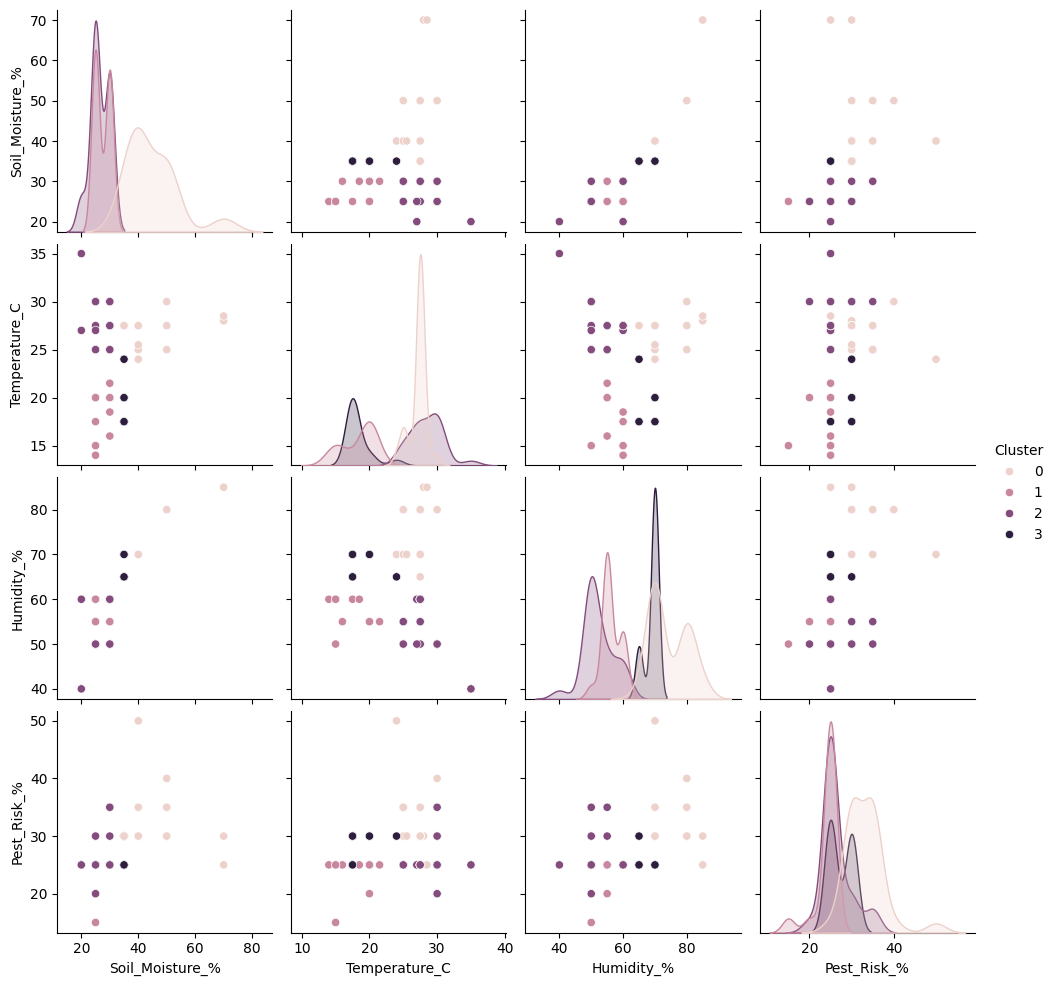

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x="Temperature_C",
    y="Pest_Risk_%",
    hue="Cluster",
    data=df,
    palette="Set2",
    alpha=0.7
)
plt.title("Crop Clustering by Temperature and Pest Risk")
sns.pairplot(df, vars=["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Pest_Risk_%"], hue="Cluster")

#plt.xlabel("Temperature (°C)")
#plt.ylabel("Pest Risk (%)")
#plt.show()

In [ ]:
print("Original rows:", len(pd.read_excel(file_path)))
print("After dropna:", len(df))
print("After feature selection:", features.dropna().shape[0])
print(df["Cluster"].value_counts())

Original rows: 84
After dropna: 84
After feature selection: 84
Cluster
0    29
2    23
1    17
3    15
Name: count, dtype: int64


In [ ]:
cluster_summary = df.groupby("Cluster")[["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Pest_Risk_%"]].mean()
print(cluster_summary)

         Soil_Moisture_%  Temperature_C  Humidity_%  Pest_Risk_%
Cluster                                                         
0              44.827586      27.189655   74.310345    33.103448
1              27.352941      18.382353   56.176471    24.117647
2              26.521739      28.434783   52.173913    26.304348
3              35.000000      18.266667   69.000000    27.333333


In [ ]:
for i in range(df["Cluster"].nunique()):
    print(f"\nCluster {i} crops:")
    print(df[df["Cluster"] == i]["Product_Name"].tolist())


Cluster 0 crops:
['Rice', 'Banana', 'Tomato', 'Black Pepper', 'Lemon', 'Bitter Gourd', 'Coconut', 'Soybean', 'Snake Gourd', 'Ridge Gourd', 'Colocasia', 'Cucumber', 'Green Cardamom', 'Amaranthus', 'Green Chili', 'Pineapple', 'Ginger', 'Brinjal', 'Sweet Potato', 'Bottle Gourd', 'Turmeric', 'Mulberry', 'Litchi', 'Yam', 'Jackfruit', 'Papaya', 'Guava', 'Okra', 'Sapota']

Cluster 1 crops:
['Wheat', 'Apple', 'Peach', 'Pear', 'Garlic', 'Cherry', 'Mustard Greens', 'Apricot', 'Coriander', 'Rajma', 'Mustard', 'Plum', 'Fenugreek', 'Coriander Leaf', 'Kinnow', 'Masoor', 'Chana']

Cluster 2 crops:
['Mango', 'Grapes', 'Pomegranate', 'Watermelon', 'Fig', 'Onion', 'Cumin', 'Niger', 'Muskmelon', 'Sunflower', 'Groundnut', 'Pumpkin', 'Ber', 'Moong', 'Mosambi', 'Dry Red Chili', 'Arhar', 'Date Palm', 'Urad', 'Orange', 'Sesame', 'Phalsa', 'Custard Apple']

Cluster 3 crops:
['Potato', 'Knol-Khol', 'Carrot', 'Cabbage', 'Lettuce', 'Broccoli', 'Cauliflower', 'Green Peas', 'French Bean', 'Strawberry', 'Radish', '

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Add cluster as a feature
X = df[["Soil_Moisture_%", "Temperature_C", "Humidity_%", "Cluster"]]
y = df["Pest_Risk_%"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE) by taking the square root of MSE
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 3.10252860730369


In [ ]:
def crop_lookup(crop_name):
    row = df[df["Product_Name"].str.lower() == crop_name.lower()]
    if row.empty:
        print("Crop not found.")
        return
    cluster = row["Cluster"].values[0]
    pest_risk = row["Pest_Risk_%"].values[0]
    irrigation = row["Irrigation_Needed"].values[0]
    fertilizer = row["Fertilizer_Required"].values[0]

    print(f"\nCrop: {crop_name}")
    print(f"Cluster: {cluster}")
    print(f"Pest Risk: {pest_risk}%")
    print(f"Irrigation Strategy: {irrigation}")
    print(f"Fertilizer Recommendation: {fertilizer}")

name=input("enter crop name")
crop_lookup(name)

enter crop namepotato

Crop: potato
Cluster: 3
Pest Risk: 25.0%
Irrigation Strategy: Yes (2–3 cycles)
Fertilizer Recommendation: Urea, DAP, MOP
